# Experiment Validation: Pre-Treatment Balance

This notebook checks whether control A and treatment B are reasonably comparable on pre-treatment characteristics. It deliberately excludes purchase, conversion, revenue, refund, and payment-failure variables because those are treatment outcomes for later analysis.

Balance is important in a randomized experiment because randomization is intended to make treatment groups comparable before treatment. Meaningful pre-treatment differences can indicate chance imbalance, assignment or exposure problems, or data-quality issues, and can make outcome comparisons harder to interpret causally.

## 1. Load the experiment data


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)

DATA_PATH = Path("../data/raw/ab_checkout_experiment_200k.csv")
df = pd.read_csv(DATA_PATH)
df["experiment_date"] = pd.to_datetime(df["experiment_date"], errors="coerce")

categorical_columns = ["device", "country", "traffic_source", "new_user"]
numerical_columns = ["sessions", "page_load_time_ms"]
required_columns = ["variant", *categorical_columns, *numerical_columns, "experiment_date"]

assert set(required_columns).issubset(df.columns), "One or more balance-analysis columns are missing."
assert df["experiment_date"].notna().all(), "Experiment dates must parse successfully."
assert set(df["variant"].dropna().unique()) == {"A", "B"}, "Expected exactly variants A and B."

df[required_columns].head()

,variant,device,country,traffic_source,new_user,sessions,page_load_time_ms,experiment_date
0,A,Desktop,AU,Organic,True,1,2536.900,2026-02-08
1,B,Desktop,US,Organic,True,1,2724.500,2026-01-07
2,A,Mobile,AU,Organic,True,1,2746.700,2026-02-09
3,B,Mobile,CA,Paid Search,True,3,2723.900,2026-01-14
4,B,Mobile,UK,Organic,True,9,2540.000,2026-01-09


## 2. Variant allocation



In [2]:
variant_allocation = (
    df["variant"]
    .value_counts()
    .reindex(["A", "B"])
    .rename("count")
    .to_frame()
)
variant_allocation["percentage"] = variant_allocation["count"].div(len(df)).mul(100)
display(variant_allocation.round({"percentage": 2}))

,count,percentage
variant,,
A,100304,50.150
B,99696,49.850


## 3. Categorical pre-treatment balance


In [3]:
categorical_balance_tables = {}

for column in categorical_columns:
    counts = pd.crosstab(df[column], df["variant"], dropna=False).reindex(columns=["A", "B"], fill_value=0)
    percentages = counts.div(counts.sum(axis=0), axis=1).mul(100)
    balance_table = pd.DataFrame(index=counts.index)
    for variant in ["A", "B"]:
        balance_table[f"{variant} count"] = counts[variant]
        balance_table[f"{variant} percentage"] = percentages[variant]
    categorical_balance_tables[column] = balance_table
    print(f"{column}")
    display(balance_table.round({"A percentage": 2, "B percentage": 2}))

device


,A count,A percentage,B count,B percentage
device,,,,
Desktop,33590,33.490,33476,33.580
Mobile,61714,61.530,61200,61.390
Tablet,5000,4.980,5020,5.040


country


,A count,A percentage,B count,B percentage
country,,,,
AU,5963,5.940,5948,5.970
CA,8101,8.080,8081,8.110
DE,10099,10.070,9833,9.860
IN,15972,15.920,15845,15.890
Other,14180,14.140,13977,14.020
UK,12004,11.970,11929,11.970
US,33985,33.880,34083,34.190


traffic_source


,A count,A percentage,B count,B percentage
traffic_source,,,,
Email,12896,12.860,12859,12.900
Organic,34333,34.230,33769,33.870
Paid Search,25883,25.800,26097,26.180
Referral,8091,8.070,8049,8.070
Social,19101,19.040,18922,18.980


new_user


,A count,A percentage,B count,B percentage
new_user,,,,
False,41278,41.150,40950,41.070
True,59026,58.850,58746,58.930


## 4. Categorical balance visualizations



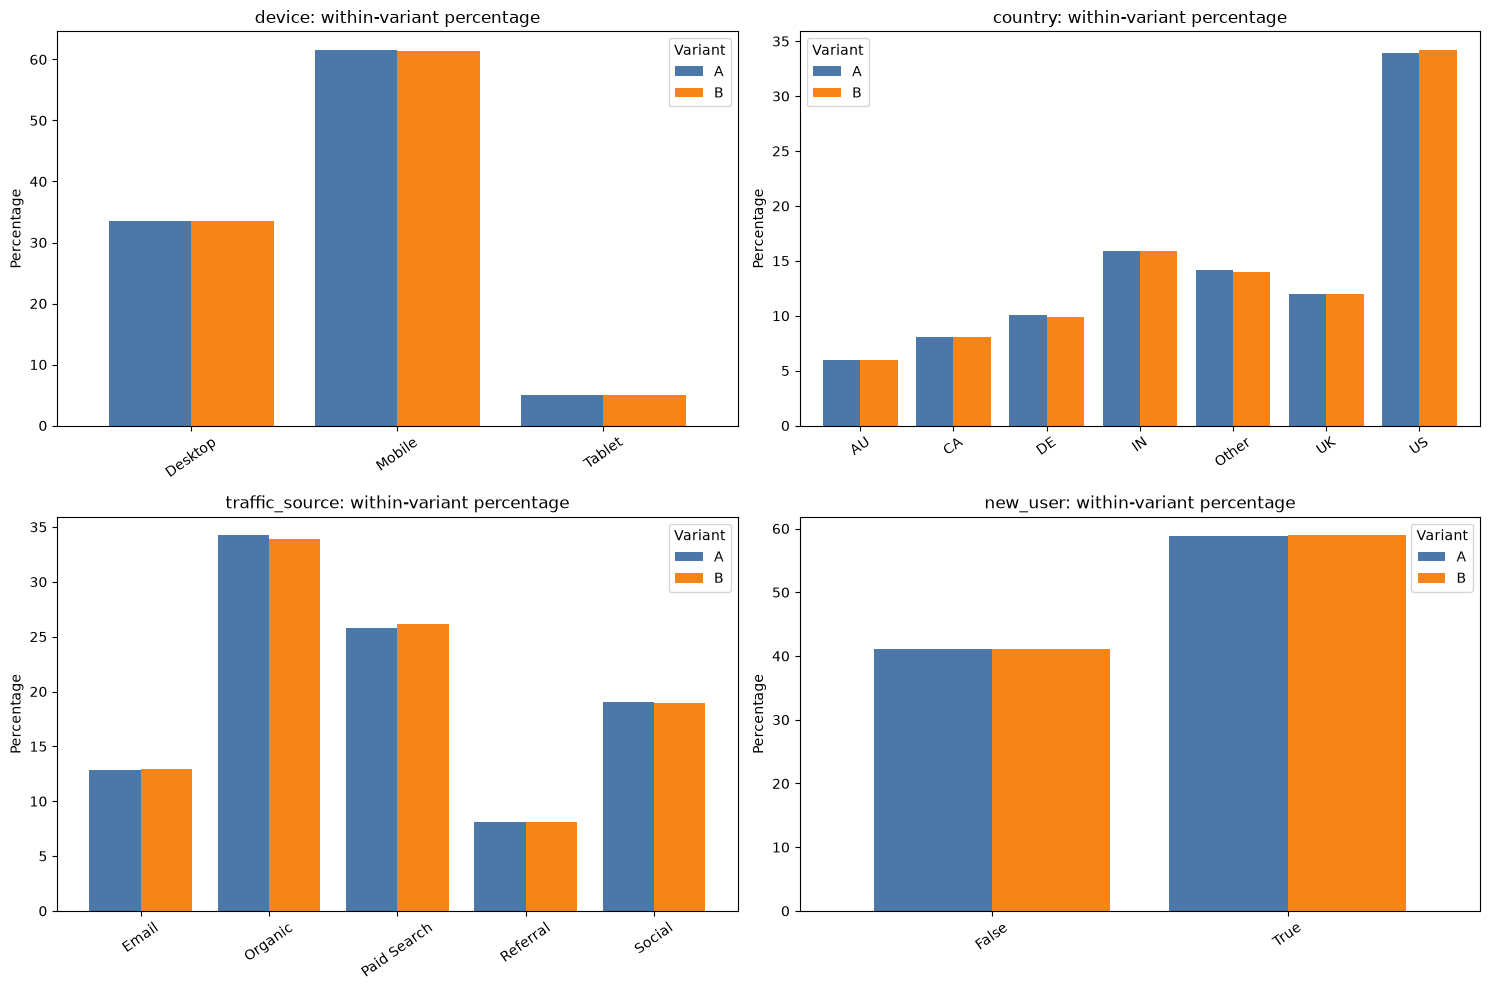

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for axis, column in zip(axes, categorical_columns):
    percentages = (
        pd.crosstab(df[column], df["variant"], normalize="columns", dropna=False)
        .reindex(columns=["A", "B"], fill_value=0)
        .mul(100)
    )
    percentages.plot(kind="bar", ax=axis, color=["#4C78A8", "#F58518"], width=0.8)
    axis.set_title(f"{column}: within-variant percentage")
    axis.set_xlabel("")
    axis.set_ylabel("Percentage")
    axis.tick_params(axis="x", rotation=35)
    axis.legend(title="Variant")

plt.tight_layout()
plt.show()

## 5. Numerical pre-treatment balance

For numerical variables, the summary includes mean, median, standard deviation, and selected percentiles within each variant.

In [5]:
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95]
numerical_balance_rows = []

for column in numerical_columns:
    for variant in ["A", "B"]:
        values = df.loc[df["variant"] == variant, column].dropna()
        summary = {
            "variable": column,
            "variant": variant,
            "count": values.size,
            "mean": values.mean(),
            "median": values.median(),
            "standard_deviation": values.std(),
        }
        summary.update({f"p{int(percentile * 100)}": values.quantile(percentile) for percentile in percentiles})
        numerical_balance_rows.append(summary)

numerical_balance = pd.DataFrame(numerical_balance_rows)
display(numerical_balance.round(3))

,variable,variant,count,mean,median,standard_deviation,p25,p50,p75,p90,p95
0,sessions,A,100304,3.489,3.000,2.519,2.000,3.000,5.000,7.000,8.000
1,sessions,B,99696,3.497,3.000,2.527,2.000,3.000,5.000,7.000,8.000
2,page_load_time_ms,A,100304,2839.962,2798.200,315.736,2615.500,2798.200,3020.100,3256.600,3419.285
3,page_load_time_ms,B,99696,2771.041,2728.700,318.369,2546.300,2728.700,2950.900,3194.300,3355.925


## 6. Numerical balance visualizations

Boxplots compare the distributions, while the overlaid histograms show whether one arm has a noticeably different shape or range.

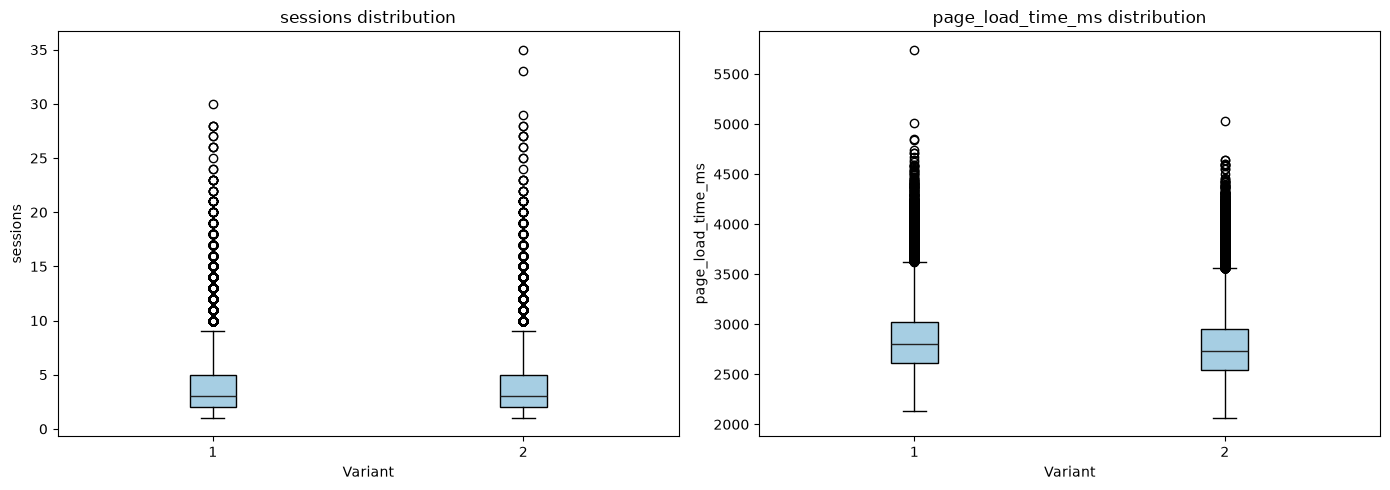

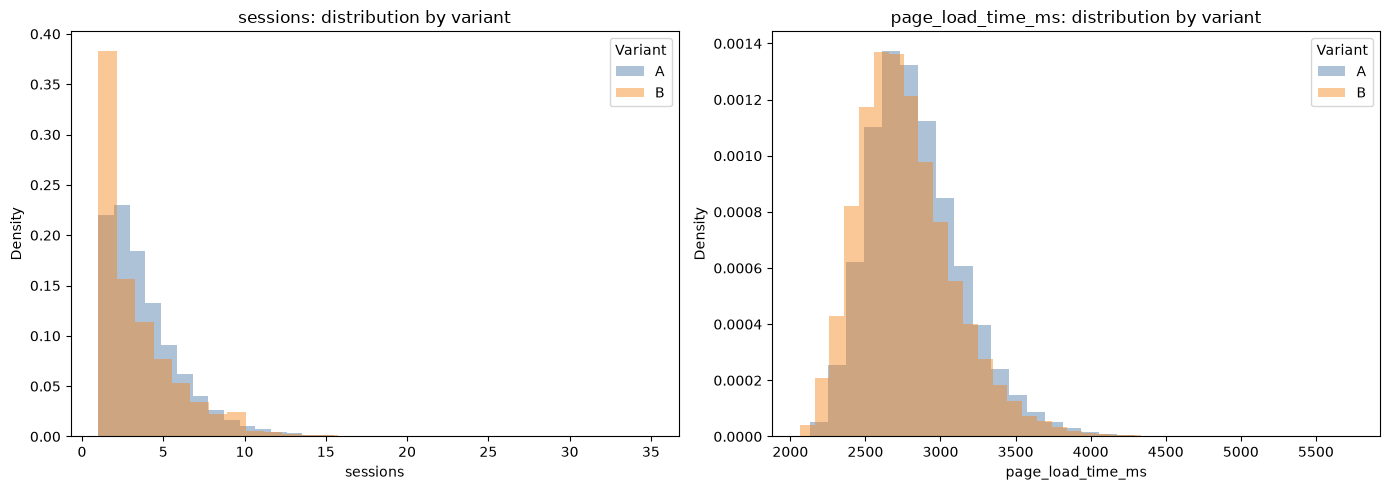

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for axis, column in zip(axes, numerical_columns):
    data_to_plot = [
        df.loc[df["variant"] == variant, column].dropna()
        for variant in ["A", "B"]
    ]
    axis.boxplot(data_to_plot, label=["A", "B"], patch_artist=True,
                 boxprops={"facecolor": "#A6CEE3"}, medianprops={"color": "#222222"})
    axis.set_title(f"{column} distribution")
    axis.set_xlabel("Variant")
    axis.set_ylabel(column)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, column in zip(axes, numerical_columns):
    for variant, color in [("A", "#4C78A8"), ("B", "#F58518")]:
        axis.hist(
            df.loc[df["variant"] == variant, column].dropna(),
            bins=30,
            density=True,
            alpha=0.45,
            label=variant,
            color=color,
        )
    axis.set_title(f"{column}: distribution by variant")
    axis.set_xlabel(column)
    axis.set_ylabel("Density")
    axis.legend(title="Variant")

plt.tight_layout()
plt.show()

## 7. Daily assignment balance



variant,A,B
experiment_date,,
2026-01-05,2174,2144
2026-01-06,2339,2351
2026-01-07,2027,2061
2026-01-08,2203,2273
2026-01-09,2115,2096


variant,A,B
count,42.000,42.000
mean,2388.190,2373.710
std,262.670,250.860
min,1860.000,1867.000
25%,2191.000,2189.250
50%,2384.500,2356.000
75%,2609.000,2594.250
max,2871.000,2892.000


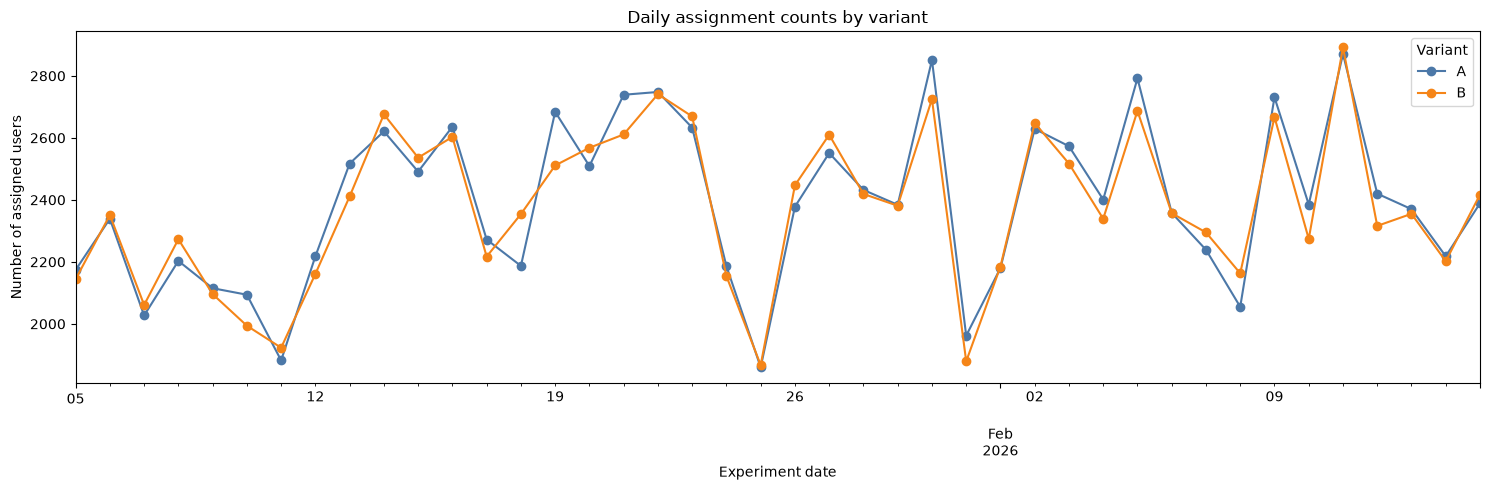

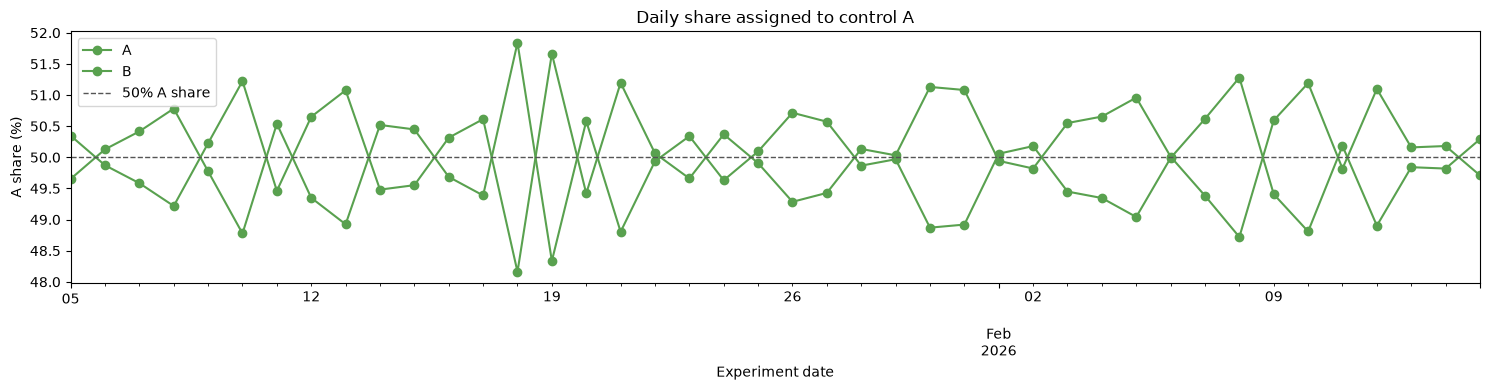

In [8]:
daily_variant_counts = (
    df.groupby(["experiment_date", "variant"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["A", "B"], fill_value=0)
    .sort_index()
)

display(daily_variant_counts.head())
display(daily_variant_counts.describe().round(2))

ax = daily_variant_counts.plot(
    figsize=(15, 5),
    marker="o",
    linewidth=1.5,
    color=["#4C78A8", "#F58518"],
)
ax.set_title("Daily assignment counts by variant")
ax.set_xlabel("Experiment date")
ax.set_ylabel("Number of assigned users")
ax.legend(title="Variant")
plt.tight_layout()
plt.show()

# Daily A share makes departures from a roughly even allocation easier to see.
daily_variant_share = daily_variant_counts.div(daily_variant_counts.sum(axis=1), axis=0).mul(100)
ax = daily_variant_share.plot(
    figsize=(15, 4),
    marker="o",
    linewidth=1.5,
    color="#59A14F",
    legend=False,
)
ax.axhline(50, color="#555555", linestyle="--", linewidth=1, label="50% A share")
ax.set_title("Daily share assigned to control A")
ax.set_xlabel("Experiment date")
ax.set_ylabel("A share (%)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Balance assessment

Randomization does not require identical samples on every characteristic. Some finite-sample differences are expected by chance. The practical question is whether the A and B distributions are broadly similar, without a systematic difference that could plausibly explain later outcome differences.

Use the tables and plots above to check for:

- Similar within-variant percentages across categorical levels.
- Similar means, medians, spread, and percentiles for `sessions` and `page_load_time_ms`.
- Similar daily A and B counts, with no sustained time period dominated by one arm.

